# 04 — Roster Composition → Win Probability

Builds a game-level dataset joining roster physical features with game outcomes,
then trains a Random Forest (and optionally a logistic regression) to predict
win probability.  Reports feature importances and cross-validated AUC.


In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.models import build_game_dataset, train_roster_model, plot_feature_importances

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
master    = pd.read_csv('../data/processed/master_labeled.csv')
schedules = pd.read_csv('../data/raw/schedules/schedules_raw.csv')
print('Master:', master.shape, '| Schedules:', schedules.shape)

Master: (80, 87) | Schedules: (1512, 10)


## Build game-level dataset

In [3]:
game_df = build_game_dataset(master, schedules)
print('Game dataset shape:', game_df.shape)
print('Win rate:', game_df['win'].mean().round(3))
game_df.head()

Game dataset shape: (799, 47)
Win rate: 0.547


,school,year,date,opponent,result,points,opp_points,home_away,conference_game,completed,...,opp_roster_depth,opp_upperclassman_ratio,opp_pass_tendency,opp_tempo,opp_spread_factor,opp_explosiveness,opp_aggression,opp_front_heaviness,opp_run_heavy,opp_pass_heavy
0,brown,2014,2014-09-20,georgetown,L,3,17,away,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,brown,2014,2014-09-27,harvard,L,14,22,home,True,True,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,brown,2014,2014-10-04,rhode island,W,20,13,away,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,brown,2014,2014-10-11,holy cross,W,27,24,home,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,brown,2014,2014-10-18,princeton,L,16,27,away,True,True,...,114.0,0.0,NaN,NaN,0.500377,NaN,NaN,0.726081,0,0


## Train Random Forest

CV AUC: 0.568 ± 0.118


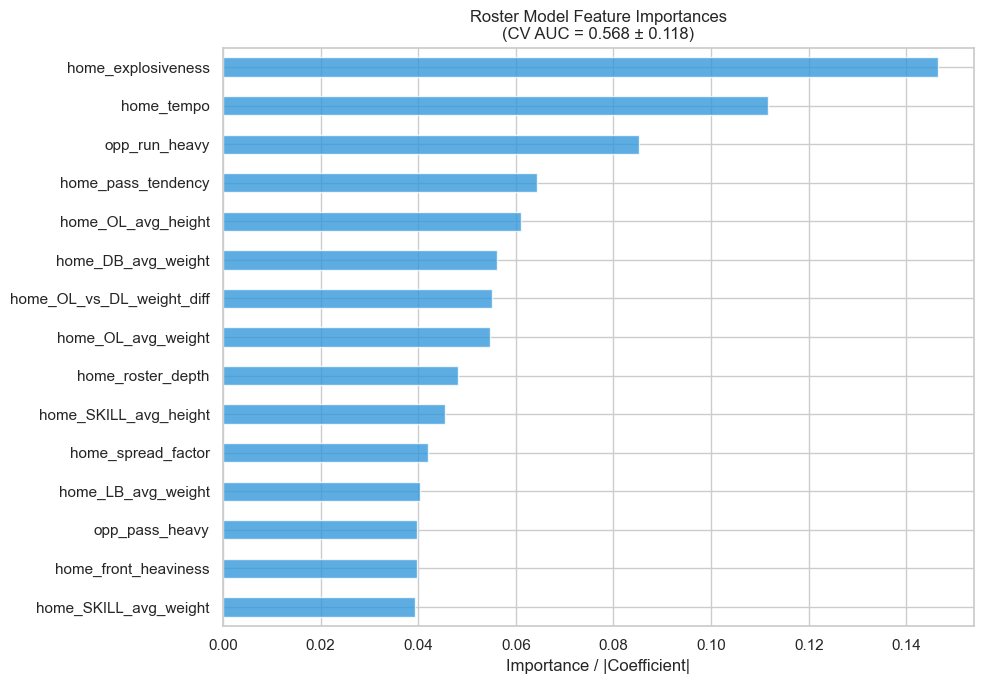

,Importance
home_explosiveness,0.146534
home_tempo,0.111636
opp_run_heavy,0.085230
home_pass_tendency,0.064354
home_OL_avg_height,0.061081
home_DB_avg_weight,0.056051
home_OL_vs_DL_weight_diff,0.055220
home_OL_avg_weight,0.054771
home_roster_depth,0.048054
home_SKILL_avg_height,0.045573


In [4]:
if len(game_df) < 30:
    print('Not enough game rows yet — run notebook 01 first to collect data.')
else:
    rf_result = train_roster_model(game_df, model_type='rf')
    print(f"CV AUC: {rf_result['cv_auc_mean']:.3f} ± {rf_result['cv_auc_std']:.3f}")
    
    fig, ax = plt.subplots(figsize=(10, 7))
    plot_feature_importances(rf_result, top_n=15, ax=ax)
    plt.savefig('../data/processed/roster_rf_importances.png', dpi=150)
    plt.show()
    
    display(rf_result['importances'].head(15).rename('Importance').to_frame())

## Compare: Logistic Regression

In [5]:
if len(game_df) >= 30:
    lr_result = train_roster_model(game_df, model_type='lr')
    print(f"Logistic CV AUC: {lr_result['cv_auc_mean']:.3f} ± {lr_result['cv_auc_std']:.3f}")
    display(lr_result['importances'].head(15).rename('|Coefficient|').to_frame())

Logistic CV AUC: 0.599 ± 0.091


,|Coefficient|
home_explosiveness,0.384218
opp_run_heavy,0.375678
opp_pass_heavy,0.148071
home_DB_avg_weight,0.129555
home_DL_avg_weight,0.100505
home_OL_avg_height,0.086309
home_pass_tendency,0.076758
home_SKILL_avg_height,0.066775
home_OL_vs_DL_weight_diff,0.060758
home_roster_depth,0.056541


## Roster matchup explorer — all 4 positional interactions

Four physically grounded matchups across a 2×2 grid:

| | Run-heavy opponent | Pass-heavy opponent |
|---|---|---|
| **Your OL** | OL run-blocking vs heavy defensive front | OL pass-blocking vs light/spread front |
| **Your DL** | DL run-stopping vs run-heavy offense | DL pass-rush vs pass-heavy offense |

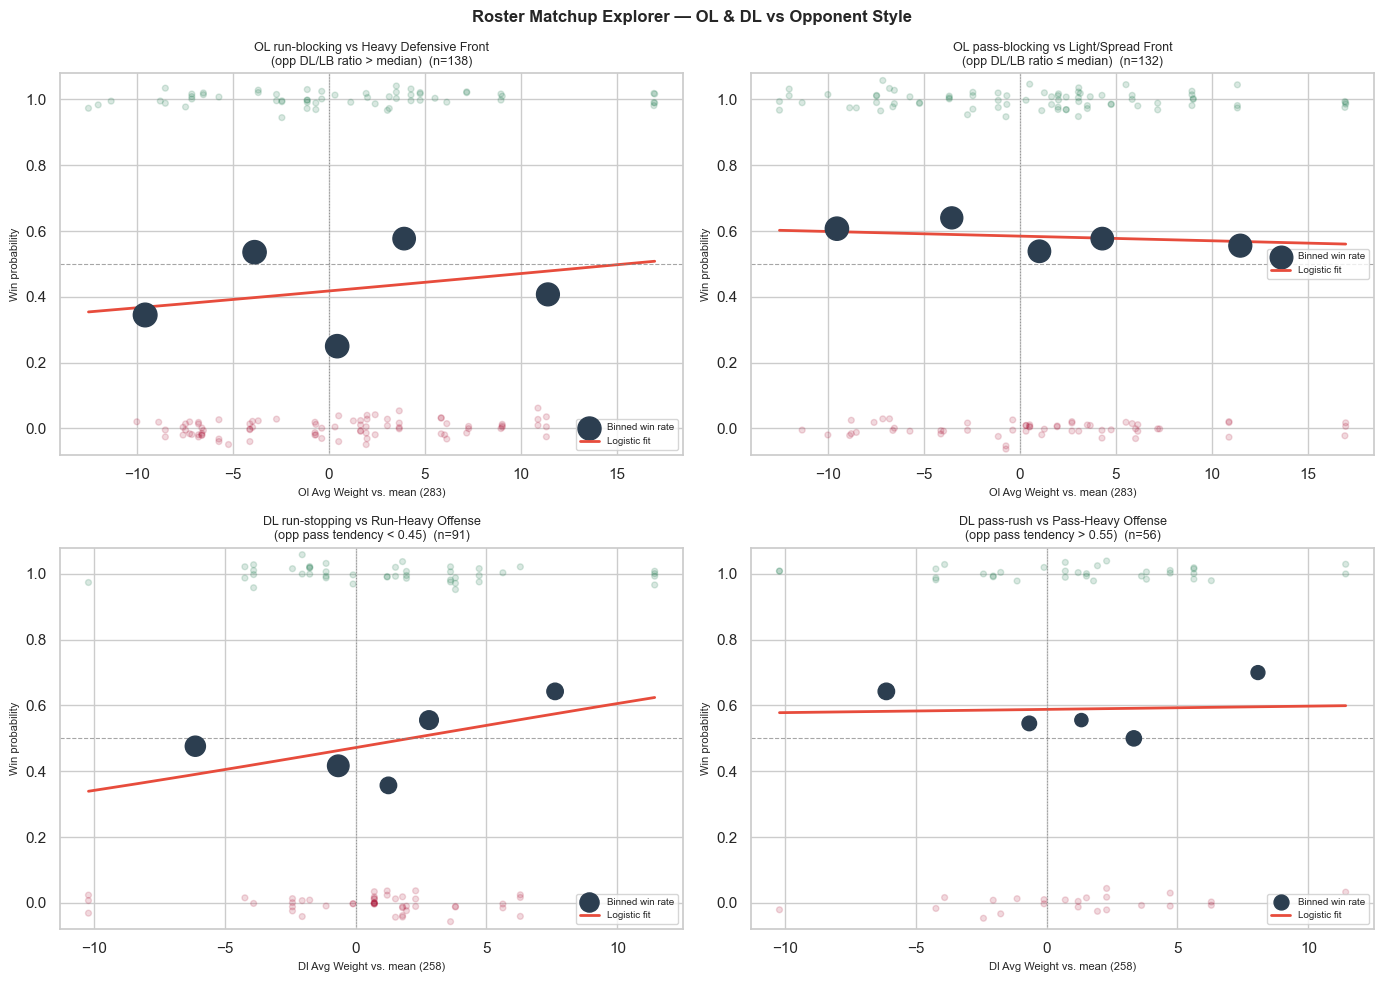

In [6]:
import statsmodels.formula.api as smf

def matchup_plot(ax, game_df, home_col, split_col, split_label,
                 split_threshold=None, split_above=True):
    col_mean = game_df[home_col].mean()
    if split_threshold is None:
        split_threshold = game_df[split_col].median()
    mask = (game_df[split_col] > split_threshold) if split_above else (game_df[split_col] <= split_threshold)
    sub = game_df[mask].dropna(subset=[home_col, 'win']).copy()

    col_label = home_col.replace('home_', '').replace('_', ' ').title()
    ax.set_title(f'{split_label}  (n={len(sub)})', fontsize=9)

    if len(sub) < 10:
        ax.text(0.5, 0.5, f'Only {len(sub)} games', ha='center', va='center',
                transform=ax.transAxes, color='grey')
        return

    sub['x'] = sub[home_col] - col_mean
    sub['win_int'] = sub['win'].astype(int)

    ax.scatter(sub['x'], sub['win_int'] + np.random.normal(0, 0.02, len(sub)),
               alpha=0.15, c=sub['win_int'], cmap='RdYlGn', s=18, zorder=1)

    try:
        sub['bin'] = pd.qcut(sub['x'], q=5, duplicates='drop')
        binned = sub.groupby('bin', observed=True)['win_int'].agg(['mean', 'count'])
        bin_centers = [iv.mid for iv in binned.index]
        ax.scatter(bin_centers, binned['mean'], s=binned['count'] * 10,
                   color='#2c3e50', zorder=3, label='Binned win rate')
    except Exception:
        pass

    try:
        m = smf.logit('win_int ~ x', data=sub).fit(disp=0)
        x_range = np.linspace(sub['x'].min(), sub['x'].max(), 200)
        pred = m.predict(pd.DataFrame({'x': x_range}))
        ax.plot(x_range, pred, color='#e74c3c', linewidth=2, zorder=2, label='Logistic fit')
    except Exception:
        pass

    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axvline(0, color='grey', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.set_xlabel(f'{col_label} vs. mean ({col_mean:.0f})', fontsize=8)
    ax.set_ylabel('Win probability', fontsize=8)
    ax.set_ylim(-0.08, 1.08)
    ax.legend(fontsize=7)


front_median = game_df['opp_front_heaviness'].median()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 1: OL matchups (opponent's DEFENSE is the relevant context)
matchup_plot(axes[0, 0], game_df,
             home_col='home_OL_avg_weight',
             split_col='opp_front_heaviness',
             split_label='OL run-blocking vs Heavy Defensive Front\n(opp DL/LB ratio > median)',
             split_threshold=front_median, split_above=True)

matchup_plot(axes[0, 1], game_df,
             home_col='home_OL_avg_weight',
             split_col='opp_front_heaviness',
             split_label='OL pass-blocking vs Light/Spread Front\n(opp DL/LB ratio ≤ median)',
             split_threshold=front_median, split_above=False)

# Row 2: DL matchups (opponent's OFFENSE is the relevant context)
matchup_plot(axes[1, 0], game_df,
             home_col='home_DL_avg_weight',
             split_col='opp_run_heavy',
             split_label='DL run-stopping vs Run-Heavy Offense\n(opp pass tendency < 0.45)',
             split_threshold=0.5, split_above=True)

matchup_plot(axes[1, 1], game_df,
             home_col='home_DL_avg_weight',
             split_col='opp_pass_heavy',
             split_label='DL pass-rush vs Pass-Heavy Offense\n(opp pass tendency > 0.55)',
             split_threshold=0.5, split_above=True)

plt.suptitle('Roster Matchup Explorer — OL & DL vs Opponent Style', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/roster_matchup_scatter.png', dpi=150)
plt.show()

## Interaction: OL weight × opponent run-heavy
Tests whether heavier OLs help more against run-heavy defenses.

In [7]:
import statsmodels.formula.api as smf

# OL weight vs win % — does a heavier OL predict winning?
sub = game_df[['win','home_OL_avg_weight']].dropna()
if len(sub) >= 30:
    m = smf.logit('win ~ home_OL_avg_weight', data=sub).fit(disp=0)
    print("OL weight → win probability:")
    print(m.summary().tables[1])

# Explosiveness vs win % — strongest feature from RF
sub2 = game_df[['win','home_explosiveness']].dropna()
if len(sub2) >= 30:
    m2 = smf.logit('win ~ home_explosiveness', data=sub2).fit(disp=0)
    print("\nExplosiveness → win probability:")
    print(m2.summary().tables[1])

# Multi-feature logit: OL weight + explosiveness + DB weight
sub3 = game_df[['win','home_OL_avg_weight','home_explosiveness','home_DB_avg_weight']].dropna()
if len(sub3) >= 30:
    m3 = smf.logit('win ~ home_OL_avg_weight + home_explosiveness + home_DB_avg_weight', data=sub3).fit(disp=0)
    print("\nCombined roster model:")
    print(m3.summary().tables[1])

OL weight → win probability:
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.6541      3.562     -0.745      0.456      -9.635       4.327
home_OL_avg_weight     0.0103      0.013      0.821      0.411      -0.014       0.035

Explosiveness → win probability:
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.7896      0.323     -2.442      0.015      -1.423      -0.156
home_explosiveness     1.7060      0.494      3.453      0.001       0.738       2.674

Combined roster model:
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -4.4459      8.473   